# Kitaev Chain: p-wave BdG Hamiltonian as an MPO

This notebook builds the Bogoliubov–de Gennes (BdG) Hamiltonian for the
**Kitaev chain** — the canonical 1D p-wave topological superconductor — as
an MPO in four steps:

1. **Kinetic MPO** on L position qubits: $H_\mathrm{kin} = -t(A+A^\dagger) - \mu I$.
2. **Pairing MPO**: forward-only NN shift $H_\mathrm{pair} = \Delta A$ where
   $A|i\rangle = |i{+}1\rangle$ (periodic boundary).
3. **BdG assembly** via `bdg_hamiltonian` from `Supercond_tk.jl`:
   $$H_\mathrm{BdG} = \tau_z \otimes H_\mathrm{kin} \;+\; \tau_+\otimes H_\mathrm{pair} \;+\; \tau_-\otimes H_\mathrm{pair}^\dagger$$
4. **KPM density of states** and a $\mu$-sweep heatmap showing the spectral
   weight redistribution across the topological transition.

**BdG spectrum** (periodic boundary conditions):
$$E(k) = \pm\sqrt{\xi(k)^2 + \Delta^2}, \qquad \xi(k) = -2t\cos k - \mu$$

The topological transition occurs at $\mu = \pm 2t$, where the minimum
quasiparticle energy $\min_k E(k)$ passes through $|\Delta|$.

**Site encoding** ($L+1$ qubits total):
$$\underbrace{b_0}_{\text{Nambu}} \underbrace{b_1 \cdots b_L}_{\text{position}} \qquad b_0=0\Rightarrow\text{particle},\quad b_0=1\Rightarrow\text{hole}$$

In [18]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding

---
## 1. System parameters and site indices

All $L+1$ sites are `Qubit` so that the KPM identity MPO (`MPO(sites,"Id")`)
works.  The **first qubit** acts as the Nambu (particle/hole) site;
the remaining $L$ qubits encode the position in quantics binary.

In [19]:
# ── Physical parameters ────────────────────────────────────────────────────────
L  = 8          # position qubits → N = 2^L = 256 sites
N  = 2^L
t  = 1.0        # NN hopping amplitude
Δ  = 0.5        # p-wave pairing amplitude
μ  = -1.0       # chemical potential  (topological phase: |μ| < 2t)

# ── Site indices ───────────────────────────────────────────────────────────────
# Using Qubit for every site so KPM's MPO(ext_sites,"Id") is valid.
# ext_sites[1] = Nambu qubit  (|0⟩ = particle, |1⟩ = hole)
# ext_sites[2:end] = L position qubits
ext_sites = siteinds("Qubit", L + 1)
nambu_s   = ext_sites[1]
pos_sites = ext_sites[2:end]

println("System: N = $N sites per Nambu sector  (L = $L qubits)")
println("BdG Hilbert space: 2N = $(2N) states  (L+1 = $(L+1) qubits)")

System: N = 256 sites per Nambu sector  (L = 8 qubits)
BdG Hilbert space: 2N = 512 states  (L+1 = 9 qubits)


---
## 2. Building the BdG Hamiltonian

### 2a. Single-particle kinetic matrix $H_\mathrm{kin} = -t(A+A^T) - \mu I$

In [20]:
# NN hopping: -t*(A + A^T)
H_hop = (-t) * TensorBinding.kineticNNN(L, pos_sites, MPO(pos_sites, "Id"), 1)
println("H_hop : L=$(length(H_hop))  maxlinkdim=$(ITensorMPS.maxlinkdim(H_hop))")

# Full single-particle kinetic matrix: add chemical potential -μ*I
H_kin = +(H_hop, (-μ) * MPO(pos_sites, "Id"); cutoff=1e-8)
println("H_kin : L=$(length(H_kin))  maxlinkdim=$(ITensorMPS.maxlinkdim(H_kin))")

H_hop : L=8  maxlinkdim=4
H_kin : L=8  maxlinkdim=4


### 2b. Pairing MPO $H_\mathrm{pair} = \Delta\, A$ (forward-only shift)

`generate_kin_u(pos_sites, N)` returns the cyclic forward shift
$A|i\rangle = |(i+1)\bmod N\rangle$ as a bond-dimension $L$ MPO.

`bdg_hamiltonian` will add `dag(H_pair) = Δ A^T` for the `τ_-` channel,
giving the full Hermitian pairing
$\tau_+\otimes\Delta A + \tau_-\otimes\Delta A^T$.

In k-space this is $\Delta e^{ik}\tau_+ + \Delta e^{-ik}\tau_-$, reproducing
the standard Kitaev chain BdG spectrum $E(k)=\pm\sqrt{\xi(k)^2+\Delta^2}$.

In [21]:
# Forward cyclic shift A: |i⟩ → |(i+1) mod N⟩
A_forward = TensorBinding.generate_kin_u(pos_sites, N)

# Pairing MPO: Δ * A  (scalar multiplication scales the first tensor)
H_pair = Δ * A_forward
println("H_pair : L=$(length(H_pair))  maxlinkdim=$(ITensorMPS.maxlinkdim(H_pair))")

H_pair : L=8  maxlinkdim=4


### 2c. Assemble the BdG Hamiltonian via `bdg_hamiltonian`

$$H_\mathrm{BdG} = \tau_z\otimes H_\mathrm{kin} + \tau_+\otimes H_\mathrm{pair} + \tau_-\otimes\mathrm{dag}(H_\mathrm{pair})$$

In [22]:
H_BdG = TensorBinding.bdg_hamiltonian(H_kin, H_pair, nambu_s)
ITensorMPS.truncate!(H_BdG; cutoff=1e-8)
println("H_BdG : L=$(length(H_BdG))  maxlinkdim=$(ITensorMPS.maxlinkdim(H_BdG))")

H_BdG : L=9  maxlinkdim=5


---
## 3. Validation: small system exact diagonalisation ($L=2$, $N=4$)

For $N=4$ sites the BdG Hilbert space has $2N=8$ states (3 qubits).

The MPO uses **open boundary conditions** (no wrap at site $N-1$).
The reference is the explicit OBC BdG matrix:

$$H_\mathrm{BdG}^\mathrm{exact} = \begin{pmatrix} H_\mathrm{kin} & \Delta A \\ \Delta A^\dagger & -H_\mathrm{kin} \end{pmatrix}$$

where $H_\mathrm{kin}$ is the $4\times4$ tridiagonal OBC tight-binding matrix and
$A$ is the OBC forward-shift matrix ($A_{i+1,i}=1$, no wrap).

In [23]:
# ── Small system: L_s = 2, N_s = 4, 2N_s = 8 BdG states ──────────────────────
L_s  = 2;  N_s = 2^L_s
ext_s = siteinds("Qubit", L_s + 1)
ns_s  = ext_s[1];  ps_s = ext_s[2:end]

H_hop_s = (-t) * TensorBinding.kineticNNN(L_s, ps_s, MPO(ps_s, "Id"), 1)
H_kin_s = +(H_hop_s, (-μ) * MPO(ps_s, "Id"); cutoff=1e-8)

A_s = TensorBinding.generate_kin_u(ps_s, N_s)
H_BdG_s = TensorBinding.bdg_hamiltonian(H_kin_s, Δ * A_s, ns_s)

# Extract full 8×8 matrix and diagonalise
M = TensorBinding.get_matrix(H_BdG_s, L_s + 1, ext_s)
eigenvalues = sort(real.(eigvals(M)))

# Reference: explicit OBC BdG matrix
H_kin_ref = diagm(0 => fill(-μ, N_s), 1 => fill(-t, N_s-1), -1 => fill(-t, N_s-1))
A_ref     = diagm(-1 => ones(N_s - 1))   # forward shift: A[i+1,i]=1, no wrap
H_BdG_ref = [H_kin_ref  Δ*A_ref; Δ*A_ref'  -H_kin_ref]
E_ref     = sort(real.(eigvals(H_BdG_ref)))

println("MPO eigenvalues:       ", round.(eigenvalues; digits=6))
println("Reference eigenvalues: ", round.(E_ref; digits=6))
println("Max error: ", maximum(abs.(eigenvalues .- E_ref)))

# Check Hermiticity (should be ~machine precision)
println("\nHermiticity check  ‖H − H†‖ = ", norm(M - M'))

MPO eigenvalues:       [-2.661772, -1.679767, -0.845906, -0.357488, 0.357488, 0.845906, 1.679767, 2.661772]
Reference eigenvalues: [-2.661772, -1.679767, -0.845906, -0.357488, 0.357488, 0.845906, 1.679767, 2.661772]
Max error: 4.884981308350689e-15

Hermiticity check  ‖H − H†‖ = 4.098562509381263e-15


---
## 4. KPM density of states  ($L=8$, $N=256$)

The DoS $\rho(\omega) = \mathrm{Tr}[\delta(\omega - H_\mathrm{BdG})]$ is computed via
the **Kernel Polynomial Method**: Chebyshev-expand $\delta(\omega - H)$,
apply Jackson damping, then take the MPO trace.

The BdG spectrum is particle-hole symmetric ($\rho(\omega) = \rho(-\omega)$) and
has a quasiparticle gap of $2|\Delta|=1$ everywhere in the Brillouin zone.

Spectral bound: scale = 3.2  (E_max ≈ 3.19)
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -3.039,  E_max = 3.0345
  center = -0.0023,  scale = 3.3404
9
16
14
20
18
20
20
22
24
27
28
31
30
34
34
37
35
40
39
42
42
44
45
47
48
49
49
50
50
51
52
53
53
53
53
54
54
55
54
55
55
54
56
58
59
62
61
65
64
68
68
70
71
74
73
75
74
78
77
78
79
80
82
83
83
85
85
86
88
88
88
89
89
91
91
92
92
93
93


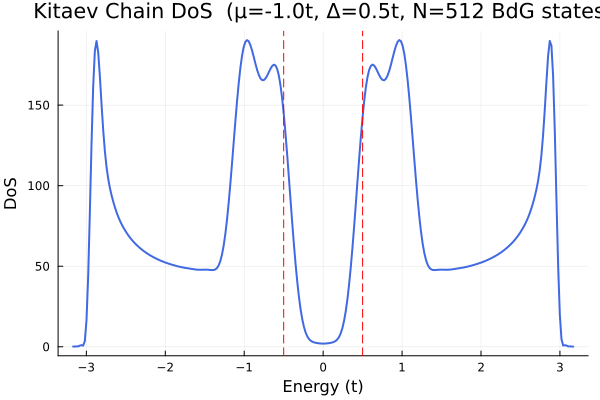

In [26]:
# ── KPM parameters ─────────────────────────────────────────────────────────────
# Spectral bound: max E(k) = sqrt((2t + |μ|)^2 + Δ^2)
E_max   = sqrt((2t + abs(μ))^2 + Δ^2) * 1.05
scale   = ceil(E_max * 10) / 10        # round up to nearest 0.1
Ncheb   = 80
maxdim  = 100
println("Spectral bound: scale = $scale  (E_max ≈ $(round(E_max; digits=2)))")

# Build Chebyshev polynomial list from H_BdG
Tn, _, _ = TensorBinding.KPM_Tn(H_BdG, Ncheb, ext_sites; maxdim=maxdim)

# ── DoS = Tr(δ(ω − H)) ────────────────────────────────────────────────────────
ω_phys = range(-scale * 0.99, scale * 0.99; length=300)
dos    = Float64[]

for ω in ω_phys
    ω_r = ω / scale
    A_mpo = TensorBinding.get_ldos_w_from_Tn(Tn, Ncheb, ω_r; maxdim=maxdim)
    push!(dos, real(tr(A_mpo)))
end

plot(ω_phys, dos;
     xlabel  = "Energy (t)",
     ylabel  = "DoS",
     title   = "Kitaev Chain DoS  (μ=$(μ)t, Δ=$(Δ)t, N=$(2N) BdG states)",
     legend  = false,
     lw      = 2,
     color   = :royalblue)
vline!([-Δ, Δ]; ls=:dash, color=:red, label="±Δ")

---
## 5. Phase diagram: DoS heatmap vs $\mu$

We sweep $\mu$ from $-4t$ to $+4t$.  The topological transition occurs at
$\mu = \pm 2t$, where the quasiparticle gap $\min_k E(k)$ reaches its minimum
value $|\Delta|$.  This is visible as a narrowing of the gap
region in the heatmap at $\mu = \pm 2$.

The intralayer Hamiltonians $H_\mathrm{kin}$ are rebuilt for each $\mu$ (only the
diagonal chemical-potential MPO changes); the pairing MPO $\Delta A$ is reused.

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -6.0147,  E_max = 6.016
  center = 0.0006,  scale = 6.6169
6
14
12
18
14
21
15
22
18
24
20
24
23
27
26
32
28
33
31
37
33
37
36
41
38
41
38
43
39
44
41
46
43
46
44
49
46
50
48
51
49
51
50
53
50
55
52
55
52
54
54
55
54
55
54
56
54
55
55
μ = -4.0 done
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -5.5203,  E_max = 5.5201
  center = -0.0001,  scale = 6.0722
5
14
7
17
9
17
11
17
13
19
15
22
18
23
22
26
25
29
25
31
25
33
27
35
30
34
31
35
33
38
35
39
36
40
38
43
40
44
43
46
45
47
45
49
46
51
49
51
50
52
51
54
52
55
53
55
54
56
55
μ = -3.5 done
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -5.0215,  E_max = 5.0212
  center = -0.0001,  scale = 5.5235
5
15
7
17
9
17
13
17
14
19
14
23
18
26
21
30
23
31
27
34
28
34
30
35
31
36
32
37
34
39
37
41
39
42
41
44
44
47
44
48
45
49
47
50
49
52
49
52
51
54
52
54
54
55
55
56
55
57
55
μ = -3.0 done
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -4.5228,  E_max = 4.5253
  center

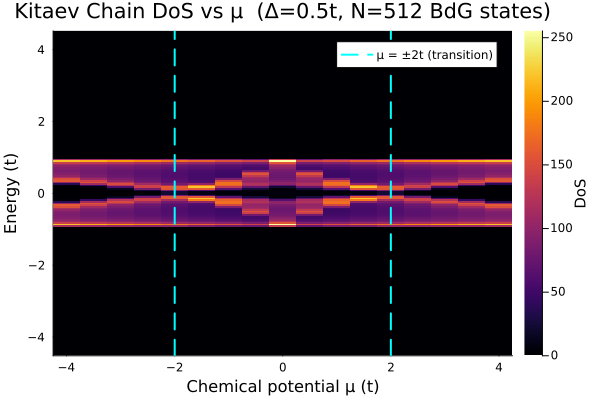

In [ ]:
# ── Sweep parameters ──────────────────────────────────────────────────────────
μ_sweep    = range(-4.0, 4.0; length=17)
ω_sweep    = range(-4.5, 4.5; length=200)
dos_sweep  = Matrix{Float64}(undef, length(ω_sweep), length(μ_sweep))

Ncheb_scan = 60
maxdim_scan = 80

# H_hop and H_pair do not depend on μ — rebuild only H_mu for each μ
H_hop_scan = (-t) * TensorBinding.kineticNNN(L, pos_sites, MPO(pos_sites, "Id"), 1)

for (iμ, μ_loc) in enumerate(μ_sweep)
    H_kin_loc = +(H_hop_scan, (-μ_loc) * MPO(pos_sites, "Id"); cutoff=1e-8)
    H_BdG_loc = TensorBinding.bdg_hamiltonian(H_kin_loc, H_pair, nambu_s)
    ITensorMPS.truncate!(H_BdG_loc; cutoff=1e-8)

    Tn_loc, _, scale_scan = TensorBinding.KPM_Tn(
        H_BdG_loc, Ncheb_scan, ext_sites; maxdim=maxdim_scan)

    for (iω, ω) in enumerate(ω_sweep)
        ω_r = ω / scale_scan
        if abs(ω_r) >= 1.0
            dos_sweep[iω, iμ] = 0.0
        else
            A_mpo = TensorBinding.get_ldos_w_from_Tn(
                Tn_loc, Ncheb_scan, ω_r; maxdim=maxdim_scan)
            dos_sweep[iω, iμ] = real(tr(A_mpo))
        end
    end
    println("μ = $(round(μ_loc; digits=1)) done")
end

heatmap(collect(μ_sweep), collect(ω_sweep), dos_sweep;
        xlabel         = "Chemical potential μ (t)",
        ylabel         = "Energy (t)",
        title          = "Kitaev Chain DoS vs μ  (Δ=$(Δ)t, N=$(2N) BdG states)",
        color          = :inferno,
        colorbar_title = "DoS")
vline!([-2t, 2t]; ls=:dash, color=:cyan, lw=2, label="μ = ±2t (transition)")

---
## Notes

**Topological phases with PBC:**  
The BdG spectrum $E(k) = \pm\sqrt{\xi(k)^2+\Delta^2}$ is always gapped for
$\Delta\neq 0$; the topological transition at $|\mu|=2t$ does not close the
bulk gap.  Instead it changes the **Z₂ topological invariant** (Pfaffian / winding
number), visible in the DoS as a shift of spectral weight toward smaller energies.

**Open boundary conditions / Majorana modes:**  
With OBC in the topological phase ($|\mu|<2t$), two Majorana zero modes appear
at the chain ends at $E=0$.  These are not accessible with the periodic shift
operators used here; OBC requires an additional row-break mask applied to the
forward-shift MPO.

**Extension to spin-½ BdG:**  
To add spin, prepend a spin qubit before the Nambu qubit using
`TensorBinding.spin_index()` and `TensorBinding.bdg_spin_hamiltonian`, which
assembles the full four-component
$\Psi = (c_\uparrow, c_\downarrow, c^\dagger_\downarrow, -c^\dagger_\uparrow)^T$
BdG Hamiltonian for singlet superconductors.